# Tugas Praktikum Kelompok — Modul 1

**Kelompok 6** — Menutup bagian **tulisan Month/Year, tulisan Valid Thru, dan Angkanya (3 bagian)** pada kartu (KTM/BNI) menggunakan OpenCV.

Langkah:
1. Akses file image lokal (KTM) dan tampilkan menggunakan OpenCV dan Matplotlib.
2. Tutup tiap bagian tertentu menggunakan fungsi yang telah dipelajari (rectangle), dikreasikan dengan warna dan ukuran berbeda per bagian.

In [6]:
import os
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt
from PIL import Image, ImageOps

try:
    from google.colab import drive
    drive.mount('/content/drive')
except ImportError:
    print("Bukan di Google Colab, skip mount drive.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1. Akses & Tampilkan Image KTM

Ganti `IMG_PATH` dengan lokasi file `KTM Femas Akbar Faturrohim.jpg` di Google Drive Anda.

Resolusi gambar: 1980 x 1272


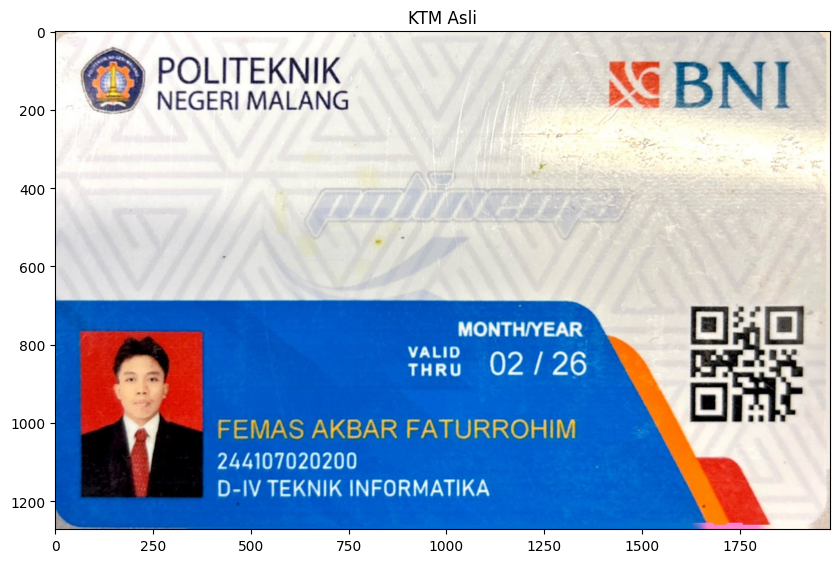

In [7]:
IMG_PATH = "/content/drive/MyDrive/KTM/KTM Femas Akbar Faturrohim.jpg"

# buka pakai PIL + exif_transpose supaya orientasi foto selalu benar sebelum diproses
pil_img = ImageOps.exif_transpose(Image.open(IMG_PATH)).convert("RGB")
img_rgb = np.array(pil_img)
print("Resolusi gambar:", img_rgb.shape[1], "x", img_rgb.shape[0])

plt.figure(figsize=(10,7))
plt.imshow(img_rgb)
plt.title("KTM Asli")
plt.show()

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 2. Tutup 3 Bagian: MONTH/YEAR, VALID THRU, dan Angka (02/26)

Koordinat berikut sudah disesuaikan dan diuji manual pada file `KTM Femas Akbar Faturrohim.jpg` (resolusi 1980x1272). Tiap bagian ditutup dengan `cv2.rectangle` warna dan ukuran berbeda (kreasi kelompok).

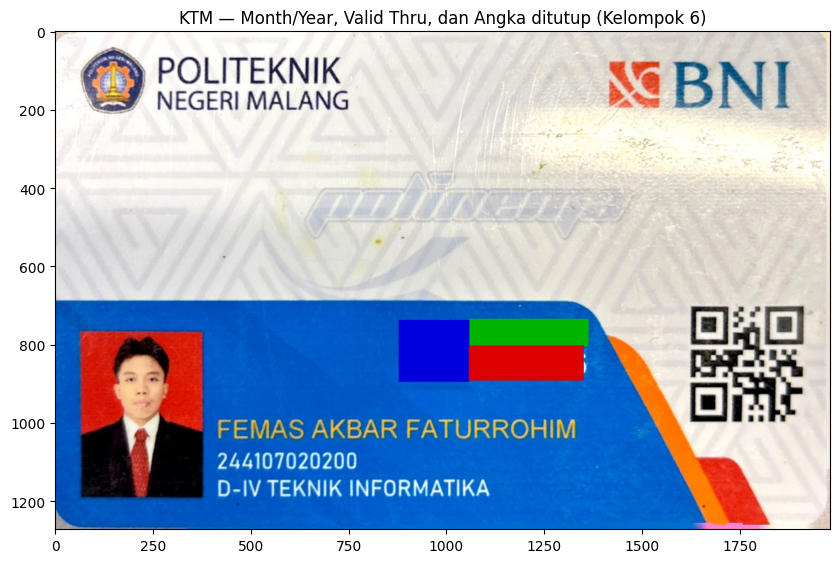

In [5]:
img_tertutup = img_rgb.copy()

# 1. Tutup tulisan "MONTH/YEAR" -> kotak hijau
cv.rectangle(img_tertutup, pt1=(1057,735), pt2=(1362,805), color=(0,180,0), thickness=-1)

# 2. Tutup tulisan "VALID THRU" -> kotak biru
cv.rectangle(img_tertutup, pt1=(878,738), pt2=(1058,895), color=(0,0,220), thickness=-1)

# 3. Tutup angka "02 / 26" -> kotak merah
cv.rectangle(img_tertutup, pt1=(1057,803), pt2=(1350,892), color=(220,0,0), thickness=-1)

plt.figure(figsize=(10,7))
plt.imshow(img_tertutup)
plt.title("KTM — Month/Year, Valid Thru, dan Angka ditutup (Kelompok 6)")
plt.show()

## Perbandingan Sebelum & Sesudah

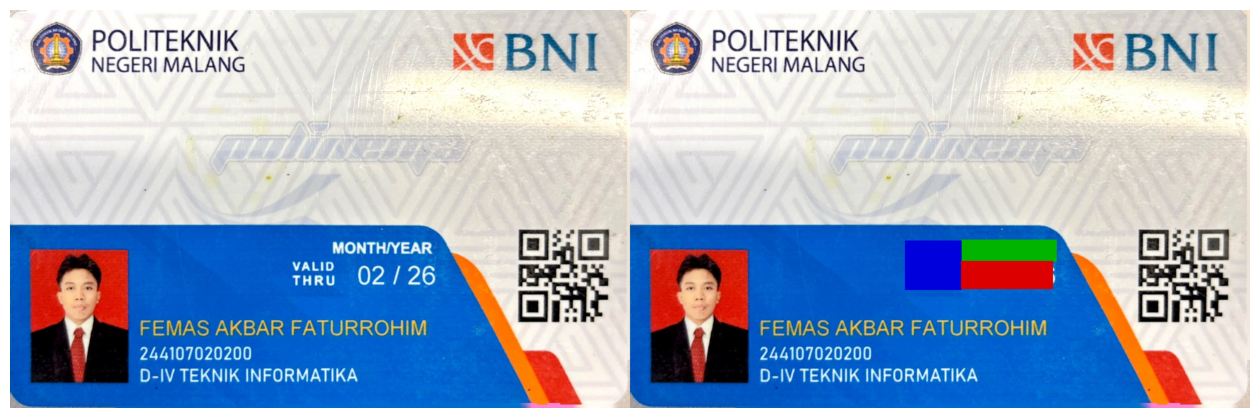

In [8]:
final_frame = cv.hconcat((img_rgb, img_tertutup))
plt.figure(figsize=(16,7))
plt.imshow(final_frame)
plt.axis('off')
plt.show()